In [335]:
import numpy as np
from math import atan2, sqrt, pi
from scipy.spatial import Delaunay
import matplotlib.pyplot as plt
from numpy.typing import NDArray

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.dpi": 100,      
    "savefig.dpi": 300,     
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 5,
    "ytick.major.size": 5,
})

In [336]:

class GPA:
    def __init__(self, matrix: NDArray[np.number]):
        """
        Gradient Pattern Analysis (GPA) implementation.

        This class implements the Gradient Pattern Analysis (GPA) method for
        two-dimensional images. Given an input image, it computes the gradient
        field, removes radially symmetric gradient vectors with respect to a
        reference center, and evaluates the four GPA moments (G1, G2, G3, and G4).

        Reference
        ---------
        Paper:

        Example
        -------
        >>> gpa = GPA(image)
        >>> gpa.setPosition(cx, cy)
        >>> results = gpa.evaluate(
        ...     mtol=0.02,
        ...     ftol=0.03,
        ...     ptol=0.01
        ... )

        The analysis center is defined with ``setPosition(cx, cy)``, where
        ``(cx, cy)`` corresponds to the point from which radial symmetry is
        evaluated. By default, the geometric center of the image is used.

        The tolerance parameters control the removal of radially symmetric
        gradient vectors:

        - ``mtol`` : Magnitude tolerance. Maximum allowed difference between the
        magnitudes of two gradient vectors for them to be considered symmetric.
        - ``ftol`` : Angular (phase) tolerance. Maximum allowed difference
        between the orientations (phases) of two gradient vectors.
        - ``ptol`` : Position tolerance. Maximum allowed deviation from perfect
        radial symmetry between two vectors.

        The ``evaluate()`` method returns a dictionary containing the requested
        GPA moments, for example:

        >>> {
        ...     "G1": 0.81,
        ...     "G2": 0.34,
        ...     "G3": 1.25,
        ...     "G4": 4.12
        ... }

        Parameters
        ----------
        matrix : numpy.ndarray
            Two-dimensional input image :math:`I(x, y)`. The input must be a
            2D NumPy array.
        """
        
        if not np.issubdtype(matrix.dtype, np.number) or np.iscomplexobj(matrix):
            raise TypeError(
                "Input matrix must contain only real numerical values."
            )

        if matrix.ndim != 2:
            raise ValueError(
                "Input matrix must be two-dimensional."
            )
        
        # Convert only the data type without creating a copy if unnecessary
        self.matrix = matrix.astype(np.float32, copy=False)


        # Input image converted to float32
        self.matrix = np.asarray(matrix, dtype=np.float32)

        # Coordinates of the image center
        self.cx = (len(self.matrix) - 1) / 2
        self.cy = (len(self.matrix[0]) - 1) / 2

        # Image dimensions
        self.rows, self.cols = self.matrix.shape


        # Gradient field components:
        #
        # ∇I = (Gx, Gy)
        #
        self.gradient_dx = None
        self.gradient_dy = None


        # Gradient field after removing
        # radially symmetric vectors
        self.gradient_asymmetric_dx = None
        self.gradient_asymmetric_dy = None


        # Gradient properties:
        #
        # phases -> orientation:
        # θ = atan2(Gy, Gx)
        #
        # mods -> magnitude:
        # |∇I| = sqrt(Gx² + Gy²)
        #
        self.phases = None
        self.mods = None


        # Coordinates of the removed points and
        # the remaining asymmetric points
        self.removedP = np.empty((0, 2), dtype=np.int32)
        self.nremovedP = np.empty((0, 2), dtype=np.int32)


        # Total number of gradient vectors and
        # remaining asymmetric vectors
        self.totalVet = self.rows * self.cols
        self.totalAssimetric = self.rows * self.cols


        # Measure of gradient orientation diversity
        self.phaseDiversity = 0.0

        # Maximum gradient magnitude found in the image
        self.maxGrad = 0.0

    def setPosition(self, cx: float, cy: float):
        """
        Set the reference center used in the GPA analysis.

        If this method is not called, the geometric center of the input image
        is used by default.

        Parameters
        ----------
        cx : float
            X-coordinate of the reference center.
        cy : float
            Y-coordinate of the reference center.
        """
        self.cx = float(cx)
        self.cy = float(cy)



    def evaluate(
        self,
        magnitude_threshold=None,
        magnitude_tolerance=None,
        mtol=None,
        ftol=None,
        ptol=None,
        rtol=None,
        mask=None,
        moments=None,
    ):
        """
        Perform Gradient Pattern Analysis (GPA) and compute the selected
        gradient moments.

        The analysis consists of the following steps:

        1. Compute the image gradient field:

            ∇I(x, y) = (Gx, Gy)

        2. Group gradient vectors according to the radial distance of their
        positions from the analysis center.

        3. Remove gradient vectors whose magnitudes are below the specified
        relative magnitude threshold.

        4. Identify and remove radially symmetric gradient-vector pairs
        based on their magnitude, orientation, and spatial position.

        5. Compute the selected GPA moments:

            G1, G2, G3, and G4.

        Parameters
        ----------
        magnitude_threshold : float, optional
            Relative magnitude threshold, expressed as a fraction of the
            maximum gradient magnitude. Gradient vectors whose magnitude
            is below or equal to this threshold are removed.

        magnitude_tolerance : float, optional
            Relative tolerance, expressed as a fraction of the maximum
            gradient magnitude, used to determine whether two gradient
            vectors have sufficiently similar magnitudes to be considered
            a symmetric pair.

        mtol : float, optional
            Deprecated compatibility parameter. If provided, its value is
            used for both ``magnitude_threshold`` and
            ``magnitude_tolerance`` when those parameters are not
            explicitly provided.

        ftol : float
            Angular tolerance used to compare the orientations of opposite
            gradient vectors.

        ptol : float
            Position tolerance used to group gradient vectors according
            to their radial distance from the analysis center.

        rtol : float, optional
            Spatial tolerance used to determine whether two gradient
            vectors are approximately opposite with respect to the
            analysis center. If ``None``, ``ptol`` is used.

        mask : numpy.ndarray, optional
            Binary mask defining the valid image region. If ``None``,
            the entire image is considered.

        moments : list of str, optional
            GPA moments to compute. Valid options are ``"G1"``, ``"G2"``,
            ``"G3"``, and ``"G4"``. If ``None``, all four moments are
            computed.

        Returns
        -------
        dict
            Dictionary containing the requested GPA moments.
        """

        if rtol is None:
            rtol = ptol

        if moments is None:
            moments = ["G1", "G2", "G3", "G4"]

        if mtol is not None:

            if magnitude_threshold is None:
                magnitude_threshold = mtol

            if magnitude_tolerance is None:
                magnitude_tolerance = mtol

        if magnitude_threshold is None:
            raise ValueError(
                "magnitude_threshold must be provided."
            )

        if magnitude_tolerance is None:
            raise ValueError(
                "magnitude_tolerance must be provided."
            )

        if ftol is None:
            raise ValueError(
                "ftol must be provided."
            )

        if ptol is None:
            raise ValueError(
                "ptol must be provided."
            )

        self.mask = mask
        if mask is None:
            self.mask = np.ones_like(self.matrix, dtype=np.float32)

        # Compute the image gradient field, as well as the
        # corresponding magnitudes and orientations.
        self._setGradients()


        # Update the image dimensions
        self.cols = len(self.matrix[0])
        self.rows = len(self.matrix)


        # Compute the radial distance map:
        #
        # r = sqrt((x - cx)² + (y - cy)²)
        #
        # Each pixel is assigned its integer radial distance
        # from the analysis center.
        radial_distance_map = np.array([
            [
                int(np.sqrt((x - self.cx)**2 + (y - self.cy)**2))
                for x in range(self.cols)
            ]
            for y in range(self.rows)
        ], dtype=np.int32)


        # Retrieve the unique radial distances present in the image
        unique_radii = np.unique(radial_distance_map).astype(np.int32)


        # Remove radially symmetric gradient vectors,
        # producing the asymmetric gradient field.
        self._update_asymmetric_mat(
            unique_radii,
            radial_distance_map,
            magnitude_threshold,
            magnitude_tolerance,
            ftol,
            ptol,
            rtol
        )


        # Allow a single GPA moment to be specified as a string
        if isinstance(moments, str):
            moments = [moments]

        elif isinstance(moments, tuple):
            moments = list(moments)


        # Map each GPA moment name to its corresponding function
        available_moments = {
            "G1": self._G1,
            "G2": self._G2,
            "G3": self._G3,
            "G4": self._G4
        }


        results = {}

        # Compute the requested GPA moments
        for moment in moments:

            if moment not in available_moments:
                raise ValueError(
                    f"Invalid GPA moment '{moment}'. "
                    f"Available options are: {list(available_moments.keys())}"
                )

            results[moment] = available_moments[moment]()

        self.radial_distance_map = radial_distance_map

        return results


        
    def _setGradients(self):
        """
        Compute the image gradient field and its associated properties.

        For an image I(x, y), the gradient is defined as:

            ∇I(x, y) = (Gx, Gy)

        where:

            Gx = ∂I/∂x

        is the intensity variation along the horizontal direction, and

            Gy = ∂I/∂y

        is the intensity variation along the vertical direction.

        The gradient magnitude is computed as:

            |∇I| = sqrt(Gx² + Gy²)

        which measures the strength of the local intensity variation.

        The gradient orientation is given by:

            θ = atan2(Gy, Gx)

        representing the angle of the gradient vector with respect to the
        x-axis.

        These quantities are subsequently used by the GPA algorithm to
        identify asymmetric structures through comparisons of gradient
        vector magnitudes and orientations.
        """

        # Compute the horizontal (gx) and vertical (gy)
        # gradients of the input image.
        #
        # gx = ∂I/∂x
        # gy = ∂I/∂y
        gy, gx = self.gradient(self.matrix)

        # Store the original gradient components.
        # These arrays remain unchanged throughout the analysis.
        self.gradient_dx = gx.copy()
        self.gradient_dy = gy.copy()

        # Create copies of the gradient components that will
        # be modified during the symmetry-removal procedure.
        self.gradient_asymmetric_dx = gx.copy()
        self.gradient_asymmetric_dy = gy.copy()

        # Compute the gradient magnitude:
        #
        # |∇I| = sqrt(Gx² + Gy²)
        self.mods = np.sqrt(gx**2 + gy**2)

        # Store the maximum gradient magnitude.
        # This value is used later for normalization:
        #
        # |∇I| / max(|∇I|)
        self.maxGrad = self.mods.max()

        # Compute the gradient orientation:
        #
        # θ = atan2(Gy, Gx)
        #
        # The result is initially in the interval [-π, π].
        angle = np.arctan2(gy, gx)

        # Convert negative angles to the interval [0, 2π].
        self.phases = np.where(
            angle >= 0,
            angle,
            angle + 2 * np.pi
        ).astype(np.float32)



    def gradient(self, matrix):
        """
        Compute the spatial gradient of a two-dimensional image using
        finite differences.

        For an image I(x, y), the gradient is defined as:

            ∇I(x, y) = (Gx, Gy)

        where:

            Gx = ∂I/∂x
            Gy = ∂I/∂y

        Central differences are used for interior pixels:

            Gx = [I(x+1, y) - I(x-1, y)] / 2
            Gy = [I(x, y+1) - I(x, y-1)] / 2

        Forward and backward differences are used at the image boundaries.

        Parameters
        ----------
        matrix : numpy.ndarray
            Two-dimensional input image.

        Returns
        -------
        tuple of numpy.ndarray
            A tuple ``(dy, dx)`` containing the vertical and horizontal
            gradient components, respectively.
        """

        # Image dimensions
        h, w = matrix.shape

        # Allocate the gradient component arrays
        dx = np.zeros((h, w), dtype=np.float32)
        dy = np.zeros((h, w), dtype=np.float32)

        # Compute the gradient at each pixel
        for j in range(h):
            for i in range(w):

                # Vertical gradient (∂I/∂y)
                #
                # Use central differences for interior pixels.
                if 0 < j < h - 1:
                    dy[j, i] = (matrix[j + 1, i] - matrix[j - 1, i]) / 2.0

                # Use forward differences along the top boundary.
                elif j < h - 1:
                    dy[j, i] = matrix[j + 1, i] - matrix[j, i]

                # Use backward differences along the bottom boundary.
                elif j > 0:
                    dy[j, i] = matrix[j, i] - matrix[j - 1, i]

                # Horizontal gradient (∂I/∂x)
                #
                # Use central differences for interior pixels.
                if 0 < i < w - 1:
                    dx[j, i] = (matrix[j, i + 1] - matrix[j, i - 1]) / 2.0

                # Use forward differences along the left boundary.
                elif i < w - 1:
                    dx[j, i] = matrix[j, i + 1] - matrix[j, i]

                # Use backward differences along the right boundary.
                elif i > 0:
                    dx[j, i] = matrix[j, i] - matrix[j, i - 1]

        return dy, dx



    def _update_asymmetric_mat(
        self,
        unique_radii,
        radial_distance_map,
        magnitude_threshold,
        magnitude_tolerance,
        ftol,
        ptol,
        rtol,
        mtol=None,
        tol=0
    ):
        """
        Remove radially symmetric contributions from the gradient field.

        Starting from the gradient field

            ∇I(x, y) = (Gx, Gy),

        where the gradient magnitude is

            |∇I| = sqrt(Gx² + Gy²)

        and the gradient orientation is

            θ = atan2(Gy, Gx),

        the algorithm groups gradient vectors according to the radial
        distance of their positions from the analysis center.

        Gradient vectors with a magnitude below the specified relative
        threshold are first removed. The remaining vectors within the
        same radial group are then compared pairwise.

        Two gradient vectors are considered radially symmetric if they
        simultaneously satisfy:

        1. Similar gradient magnitudes:

            ||∇I₁| - |∇I₂|| ≤ magnitude_tolerance · max(|∇I|)

        2. Approximately opposite orientations:

            |Δθ - π| ≤ ftol

        3. Approximately opposite spatial positions with respect to
        the analysis center:

            |x₁ + x₂ - 2cx| ≤ rtol

            |y₁ + y₂ - 2cy| ≤ rtol

        where Δθ is the angular difference between the two gradient
        vectors and (cx, cy) is the analysis center.

        When these conditions are satisfied, both vectors are removed
        by setting

            Gx = 0
            Gy = 0

        yielding the asymmetric gradient field

            ∇I_asym = (Gx_asym, Gy_asym),

        which contains only the gradient vectors associated with
        asymmetric image structures.

        Parameters
        ----------
        unique_radii : numpy.ndarray
            Array containing the distinct radial distances.

        radial_distance_map : numpy.ndarray
            Integer-valued radial distance of every pixel from the
            analysis center.

        magnitude_threshold : float
            Relative magnitude threshold, expressed as a fraction of
            the maximum gradient magnitude. Gradient vectors whose
            magnitude is below or equal to this threshold are removed
            from the gradient field.

        magnitude_tolerance : float
            Relative tolerance, expressed as a fraction of the maximum
            gradient magnitude, used to determine whether two gradient
            vectors have sufficiently similar magnitudes to be considered
            a symmetric pair.

        ftol : float
            Angular tolerance used to identify gradient vectors with
            approximately opposite orientations.

        ptol : float
            Position tolerance used when grouping gradient vectors
            according to their radial distance from the analysis center.

        rtol : float, optional
            Spatial tolerance used to determine whether two gradient
            vectors are approximately opposite with respect to the
            analysis center. If not provided, the value of `ptol` is
            used by default.
        """

        # Convert the arrays to the same data types used by the
        # original Cython implementation.
        mask = np.asarray(self.mask, dtype=np.float32)
        unique_radii = np.asarray(unique_radii, dtype=np.int32)
        radial_distance_map = np.asarray(radial_distance_map, dtype=np.int32)

        # Convert the tolerance values to float32.
        if mtol is not None:
            mtol = np.float32(mtol)
        ftol = np.float32(ftol)
        ptol = np.float32(ptol)
        rtol = np.float32(rtol)

        removedP = []

        # Process each radial distance.
        # Gradient vectors belonging to the same radial group
        # may form symmetric pairs.
        for radius in unique_radii:

            x2 = []
            y2 = []

            # Collect all pixels belonging to the current
            # radial distance.
            for py in range(self.rows):
                for px in range(self.cols):

                    if abs(radial_distance_map[py, px] - radius) <= abs(ptol):
                        x2.append(px)
                        y2.append(py)

            # Pixel coordinates within the current radial group.
            x = np.array(x2, dtype=np.int32)
            y = np.array(y2, dtype=np.int32)

            lx = len(x)

            # Compare every pair of gradient vectors in the
            # current radial group.
            # cont = 0
            for i in range(lx):

                px = x[i]
                py = y[i]

                if mask[py, px] == 0:
                    continue


                if (
                    self.gradient_asymmetric_dx[py, px] == 0.0
                    and self.gradient_asymmetric_dy[py, px] == 0.0
                ):
                    continue

                # Remove gradient vectors whose magnitude is
                # below the specified threshold.
                if (self.mods[py, px] / self.maxGrad) <= magnitude_threshold:

                    self.gradient_asymmetric_dx[py, px] = np.float32(0.0)
                    self.gradient_asymmetric_dy[py, px] = np.float32(0.0)

                    continue

                # Compare the current vector with the remaining
                # vectors in the same radial group.
                for j in range(i + 1, lx):

                    px2 = x[j]
                    py2 = y[j]

                    # if mask[py2, px2] == 0:
                    #     continue

                    if mask[py2, px2] == 0:
                        continue

                    if (
                        self.gradient_asymmetric_dx[py2, px2] == 0.0
                        and self.gradient_asymmetric_dy[py2, px2] == 0.0
                    ):
                        continue



                    if tol is not None:
                        gx1 = self.gradient_asymmetric_dx[py, px]
                        gy1 = self.gradient_asymmetric_dy[py, px]

                        gx2 = self.gradient_asymmetric_dx[py2, px2]
                        gy2 = self.gradient_asymmetric_dy[py2, px2]

                        # IDL criterion: magnitude of the vector sum
                        r = np.sqrt(
                            (gx1 + gx2)**2 +
                            (gy1 + gy2)**2
                        )

                        # Normalize the residual
                        denom = np.sqrt(gx1**2 + gy1**2) + np.sqrt(gx2**2 + gy2**2)

                        if denom > 0:
                            tolerance_error = r / denom
                        else:
                            tolerance_error = 0.0

                        print(f"Tolerance error: {tolerance_error}")

                        if tolerance_error <= tol:
                            # Check whether the gradient vectors have
                            # approximately opposite orientations.
                            # angle_opposite = (
                            #     abs(
                            #         self._angleDifference(
                            #             self.phases[py, px],
                            #             self.phases[py2, px2]
                            #         ) - np.pi
                            #     ) <= ftol
                            # )

                            # Check whether the two pixels are opposite
                            # with respect to the analysis center.
                            # (px, py) + (px2, py2) ≈ 2*(cx, cy)
                            position_opposite = (
                                abs((px + px2) - 2*self.cx) <= rtol
                                and
                                abs((py + py2) - 2*self.cy) <= rtol
                            )

                            if position_opposite:

                                self.gradient_asymmetric_dx[py, px] = np.float32(0.0)
                                self.gradient_asymmetric_dy[py, px] = np.float32(0.0)

                                self.gradient_asymmetric_dx[py2, px2] = np.float32(0.0)
                                self.gradient_asymmetric_dy[py2, px2] = np.float32(0.0)

                                break
                    
                    elif abs(self.mods[py, px] - self.mods[py2, px2]) <= magnitude_tolerance * self.maxGrad:
                    
                        # Check whether the gradient vectors have
                        # approximately opposite orientations.
                        angle_opposite = (
                            abs(
                                self._angleDifference(
                                    self.phases[py, px],
                                    self.phases[py2, px2]
                                ) - np.pi
                            ) <= ftol
                        )

                        # Check whether the two pixels are opposite
                        # with respect to the analysis center.
                        # (px, py) + (px2, py2) ≈ 2*(cx, cy)
                        position_opposite = (
                            abs((px + px2) - 2*self.cx) <= rtol
                            and
                            abs((py + py2) - 2*self.cy) <= rtol
                        )

                        if angle_opposite and position_opposite:

                            self.gradient_asymmetric_dx[py, px] = np.float32(0.0)
                            self.gradient_asymmetric_dy[py, px] = np.float32(0.0)

                            self.gradient_asymmetric_dx[py2, px2] = np.float32(0.0)
                            self.gradient_asymmetric_dy[py2, px2] = np.float32(0.0)

                            break

        # Preserve compatibility with the original Cython implementation.
        if len(removedP) > 0:
            self.removedP = np.array(removedP, dtype=np.int32)

        # Reset the vector counters.
        self.totalVet = 0
        self.totalAssimetric = 0

        nremovedP = []

        # Count the remaining asymmetric vectors.
        for j in range(self.rows):
            for i in range(self.cols):

                # Valid asymmetric gradient vector.
                if (
                    (
                        self.gradient_asymmetric_dy[j, i] != 0.0
                        or self.gradient_asymmetric_dx[j, i] != 0.0
                    )
                    and mask[j, i] != 0.0
                ):
                    nremovedP.append([j, i])
                    self.totalVet += 1

                # Gradient vector removed due to radial symmetry.
                elif mask[j, i] != 0.0:
                    removedP.append([j, i])
                    self.totalVet += 1
                    self.totalAssimetric += 1

        # Store the remaining asymmetric points.
        if len(nremovedP) > 0:
            self.nremovedP = np.array(nremovedP, dtype=np.int32)
    
    # def _angleDifference(self, a1, a2):
    #   return min(abs(a1-a2), abs(abs(a1-a2)-2*np.pi))

    def _angleDifference(self, a1, a2):
        diff = abs(a1-a2)
        return min(diff, 2*np.pi-diff)
    

    
    def _G1(self):
        """
        Compute the first-order Gradient Pattern Analysis (G1) index.

        This implementation reproduces in Python the original first-order
        Gradient Pattern Analysis formulation introduced by Rosa, Sharma,
        and Valdivia (1999). The mathematical procedure and normalization
        used in the original implementation are preserved; only the
        programming language has been changed from the original
        implementation to Python.

        The G1 index is calculated from the Delaunay triangulation of the
        non-zero asymmetric gradient vectors. The spatial position of each
        gradient vector is combined with its normalized gradient components
        to define the points used in the triangulation.

        The number of unique Delaunay edges is compared with the total
        number of non-zero asymmetric gradient vectors according to

            G1 = (N_edges - N_asymmetric) / N_asymmetric

        where ``N_edges`` is the number of unique edges in the Delaunay
        triangulation and ``N_asymmetric`` is the number of non-zero
        asymmetric gradient vectors.

        The gradient components are rescaled using the same normalization
        factor as in the original implementation. This scaling affects only
        the spatial representation of the gradient vectors used to construct
        the asymmetric triangulation.

        References
        ----------
        Rosa, R. R., Sharma, A. S., & Valdivia, J. A. (1999).
        "Characterization of Asymmetric Fragmentation Patterns in Spatially
        Extended Systems."
        International Journal of Modern Physics C, 10(1), 147-163.
        https://doi.org/10.1142/S0129183199000103

        Notes
        -----
        This Python implementation is intended to preserve the mathematical
        formulation of the original 1999 method, rather than introduce a new
        definition of the G1 parameter.
        """

        dx = self.gradient_asymmetric_dx
        dy = self.gradient_asymmetric_dy

        # Select non-zero asymmetric gradient vectors
        # Equivalent to:
        #
        # naozero = WHERE((dx NE 0) OR (dy NE 0))

        naozero = np.flatnonzero(
            (dx != 0) | (dy != 0)
        )

        self.totalAssimetric = len(naozero)

        if self.totalAssimetric < 3:
            self.n_edges = 0
            G1 = 0.0
            return G1

        # IDL factor

        factor = 1.0 / (
            2.0 * np.sqrt(
                np.abs(np.max(dx))**2 +
                np.abs(np.max(dy))**2
            )
        )

        # Convert flattened IDL indices to (row, column)

        rows, cols = np.unravel_index(
            naozero,
            dx.shape
        )

        # IDL:
        #
        # vvx = dx(naozero)*factor + naozero MOD my
        # vvy = dy(naozero)*factor + naozero/my

        self.vvx = (
            dx[rows, cols] * factor
            + cols
        )

        self.vvy = (
            dy[rows, cols] * factor
            + rows
        )

        # Delaunay triangulation

        triangulation_points = np.column_stack(
            (self.vvx, self.vvy)
        ).astype(np.float64)

        self.triangles = Delaunay(
            triangulation_points
        )

        # Number of unique Delaunay edges

        indptr, indices = (
            self.triangles.vertex_neighbor_vertices
        )

        self.n_edges = len(indices) / 2.0

        # GPA / Fragmentation

        G1 = (
            self.n_edges - self.totalAssimetric
        ) / self.totalAssimetric

        return G1

    def _G2(self):
        """
        Compute the second Gradient Pattern Analysis (GPA) moment.

        The second GPA moment is defined as

            G2 = (V / VA) · (2 - D)

        where

            V  = number of remaining asymmetric gradient vectors,
            VA = total number of valid gradient vectors, and

            D = |Σvi| / Σ|vi|

        is the vectorial diversity (or alignment) measure. Values of
        ``D`` close to 1 indicate highly aligned gradient vectors,
        whereas smaller values indicate greater directional diversity.

        Returns
        -------
        float
            The second GPA moment (G2).
        """

        # Count the remaining asymmetric gradient vectors.
        if len(self.nremovedP) > 0:
            self.totalAssimetric = len(self.nremovedP[:, 0])
        else:
            self.totalAssimetric = 0

        # Compute the vectorial diversity:
        #
        # D = |Σvi| / Σ|vi|
        self.phaseDiversity = self._vectorialVariety()

        # Compute the second GPA moment:
        #
        # G2 = (V / VA) · (2 - D)
        G2 = (
            float(self.totalAssimetric) / float(self.totalVet)
        ) * (2.0 - self.phaseDiversity)

        return G2

    
    def _G3(self):
            
        return
    def _G4(self):
            
        return

    def _vectorialVariety(self):
        """
        Compute the vectorial diversity (alignment) measure.

        The quantity is defined as

            D = |Σvi| / Σ|vi|

        where

            vi = (Gx, Gy)

        is an asymmetric gradient vector.

        This measure quantifies the overall alignment of the asymmetric
        gradient vectors. Values close to 1 indicate that the vectors are
        predominantly aligned in the same direction, whereas values close
        to 0 indicate a more diverse or isotropic distribution of
        orientations.

        Returns
        -------
        float
            The vectorial diversity (alignment) measure.
        """

        sum_x = 0.0
        sum_y = 0.0
        sum_magnitude = 0.0

        # No asymmetric vectors are available.
        if self.totalAssimetric < 1:
            return 0.0

        # Sum the asymmetric gradient vectors.
        for i in range(self.totalAssimetric):

            row = self.nremovedP[i, 0]
            col = self.nremovedP[i, 1]

            # Gradient magnitude:
            #
            # |vi| = sqrt(Gx² + Gy²)
            magnitude = self.mods[row, col]

            sum_x += self.gradient_dx[row, col]
            sum_y += self.gradient_dy[row, col]

            # Sum of the vector magnitudes.
            sum_magnitude += magnitude

        if sum_magnitude <= 0.0:
            return 0.0

        # Compute the vectorial diversity:
        #
        # D = sqrt((ΣGx)² + (ΣGy)²) / Σ|vi|
        vectorial_diversity = (
            np.sqrt(sum_x**2 + sum_y**2) / sum_magnitude
        )

        return vectorial_diversity

    def plot_delaunay_triangulation(
        self,
        show_image=True,
        show_scale=True,
        show_center=True,
        line_color="red"
    ):
        """
        Plot the asymmetric gradient field and its Delaunay triangulation.

        The triangulation is constructed from the positions of the
        remaining asymmetric gradient vectors.

        Parameters
        ----------
        show_image : bool, default=True
            If True, display the original matrix as the background.

        show_scale : bool, default=True
            If True, display the x and y axes, including tick marks and
            labels. If False, hide the ticks and labels while preserving
            the plot area.

        show_center : bool, default=True
            If True, display the analysis center.

        line_color : str, default="red"
            Color of the Delaunay triangulation lines.
        """

        gx = self.gradient_asymmetric_dx
        gy = self.gradient_asymmetric_dy

        valid = (
            self.mask.astype(bool)
            & ((gx != 0) | (gy != 0))
        )

        has_vectors = np.any(valid)

        # Pixel-centered coordinates
        y, x = np.mgrid[
            0:self.rows,
            0:self.cols
        ]

        x = x + 0.5
        y = y + 0.5

        # Determine plotting region

        if max(self.rows, self.cols) > 50 and has_vectors:

            rows, cols = np.where(valid)

            margin = 2

            ymin = max(rows.min() - margin, 0)
            ymax = min(rows.max() + margin + 1, self.rows)

            xmin = max(cols.min() - margin, 0)
            xmax = min(cols.max() + margin + 1, self.cols)

        else:

            ymin = 0
            ymax = self.rows

            xmin = 0
            xmax = self.cols

        
        # No asymmetric vectors

        if not has_vectors:

            print("No asymmetric gradient vectors remaining.")
            return

        # Figure

        fig, ax = plt.subplots(figsize=(5, 5))

        # Background image

        if show_image:

            ax.imshow(
                self.matrix[ymin:ymax, xmin:xmax],
                cmap="gray",
                origin="lower",
                extent=[
                    xmin,
                    xmax,
                    ymin,
                    ymax
                ]
            )

        # Normalize vectors for visualization

        max_gx = np.max(np.abs(gx))
        max_gy = np.max(np.abs(gy))

        factor = 1.0 / (
            2.0 * np.sqrt(
                max_gx**2 +
                max_gy**2
            )
        )

        u = gx * factor
        v = gy * factor

        # Asymmetric gradient vectors

        ax.quiver(
            x[valid],
            y[valid],
            u[valid],
            v[valid],
            color=line_color,
            angles="xy",
            scale_units="xy",
            scale=1,
            width=0.003
        )

        # Delaunay triangulation

        ax.triplot(
            self.vvx + 0.5,
            self.vvy + 0.5,
            self.triangles.simplices,
            color=line_color,
            linewidth=0.8
        )

        # Triangulation points

        ax.scatter(
            self.vvx + 0.5,
            self.vvy + 0.5,
            s=8,
            color=line_color,
            zorder=3
        )

        # Analysis center

        if show_center:

            ax.scatter(
                self.cx + 0.5,
                self.cy + 0.5,
                marker="x",
                color="blue",
                s=100,
                linewidths=2,
                zorder=4
            )

        # Plot limits

        margin = 0.5

        ax.set_xlim(xmin - margin, xmax + margin)
        ax.set_ylim(ymin - margin, ymax + margin)

        # Minimal style

        if show_scale:

            ax.set_xlabel("x")
            ax.set_ylabel("y")

        else:

            ax.set_xticks([])
            ax.set_yticks([])

            ax.set_xlabel("")
            ax.set_ylabel("")

            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_linewidth(0.8)

        ax.set_aspect("equal")

        plt.tight_layout(pad=0)

        plt.show()

    def plot_gradient_field(
        self,
        fixed_length=True,
        show_image=True,
        show_scale=True,
        show_center=True,
        color="red"
    ):
        """
        Plot the image gradient field as a vector field.

        Each arrow represents a gradient vector:

            ∇I = (Gx, Gy)

        Parameters
        ----------
        fixed_length : bool, default=True
            If True, normalize all vectors to the same length so that
            only their orientations are represented. If False, preserve
            the relative gradient magnitudes.

        show_image : bool, default=True
            If True, display the original matrix as the background of
            the gradient field.

        show_scale : bool, default=True
            If True, display the x and y axes, including tick marks and
            labels. If False, hide the ticks and labels while preserving
            the plot area.

        show_center : bool, default=True
            If True, display the analysis center.

        color : str, default="red"
            Color of the gradient vectors.
        """

        # Pixels where vectors will be displayed

        valid = self.mask.astype(bool)

        gx = self.gradient_dx
        gy = self.gradient_dy

        # Coordinate grid

        y, x = np.mgrid[
            0:self.rows,
            0:self.cols
        ]

        x = x + 0.5
        y = y + 0.5

        # Normalize vectors or preserve magnitudes

        if fixed_length:

            magnitude = np.sqrt(gx**2 + gy**2)

            # Avoid division by zero
            magnitude[magnitude == 0] = 1

            scale = 0.5

            u = (gx / magnitude) * scale
            v = (gy / magnitude) * scale

        else:

            max_gx = np.max(np.abs(gx))
            max_gy = np.max(np.abs(gy))

            factor = 1.0 / (
                2.0 * np.sqrt(
                    max_gx**2 +
                    max_gy**2
                )
            )

            u = gx * factor
            v = gy * factor

        # Bounding box of the mask

        rows, cols = np.where(valid)

        margin = 2

        ymin = max(rows.min() - margin, 0)
        ymax = min(rows.max() + margin + 1, self.rows)

        xmin = max(cols.min() - margin, 0)
        xmax = min(cols.max() + margin + 1, self.cols)

        # Figure

        fig, ax = plt.subplots(figsize=(5, 5))

        # Background image

        if show_image:

            ax.imshow(
                self.matrix[ymin:ymax, xmin:xmax],
                cmap="gray",
                origin="lower",
                extent=[
                    xmin,
                    xmax,
                    ymin,
                    ymax
                ]
            )

        # Gradient vectors

        ax.quiver(
            x[valid],
            y[valid],
            u[valid],
            v[valid],
            color=color,
            angles="xy",
            scale_units="xy",
            scale=1
        )

        # Analysis center

        if show_center:

            ax.scatter(
                self.cx + 0.5,
                self.cy + 0.5,
                marker="x",
                color="blue",
                s=150,
                linewidths=2
            )

        # Plot limits

        margin = 0.5

        ax.set_xlim(xmin - margin, xmax + margin)
        ax.set_ylim(ymin - margin, ymax + margin)

        # Minimal style

        if show_scale:

            ax.set_xlabel("x")
            ax.set_ylabel("y")

        else:

            # Remove ticks and labels
            ax.set_xticks([])
            ax.set_yticks([])

            ax.set_xlabel("")
            ax.set_ylabel("")

            # Keep the boundary of the image/plot
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_linewidth(0.8)

        ax.set_aspect("equal")

        plt.tight_layout(pad=0)

        plt.show()

    def plot_asymmetric_gradient_field(
        self,
        fixed_length=True,
        show_image=True,
        show_scale=True,
        show_center=True,
        color="red"
    ):
        """
        Plot the asymmetric gradient field obtained after removing
        symmetric gradient contributions.

        Parameters
        ----------
        fixed_length : bool, default=True
            If True, normalize all vectors to the same length so that
            only their orientations are represented. If False, preserve
            the relative gradient magnitudes.

        show_image : bool, default=True
            If True, display the original matrix as the background of
            the gradient field.

        show_scale : bool, default=True
            If True, display the x and y axes, including tick marks and
            labels. If False, hide the ticks and labels while preserving
            the plot area.

        show_center : bool, default=True
            If True, display the analysis center used to identify
            symmetric gradient contributions.

        color : str, default="red"
            Color of the asymmetric gradient vectors.
        """

        gx = self.gradient_asymmetric_dx
        gy = self.gradient_asymmetric_dy

        valid = (
            self.mask.astype(bool)
            & ((gx != 0) | (gy != 0))
        )

        has_vectors = np.any(valid)

        # Coordinate grid

        y, x = np.mgrid[
            0:self.rows,
            0:self.cols
        ]

        x = x + 0.5
        y = y + 0.5

        # Determine plotting region

        if max(self.rows, self.cols) > 50 and has_vectors:

            rows, cols = np.where(valid)

            margin = 2

            ymin = max(rows.min() - margin, 0)
            ymax = min(rows.max() + margin + 1, self.rows)

            xmin = max(cols.min() - margin, 0)
            xmax = min(cols.max() + margin + 1, self.cols)

        else:

            ymin = 0
            ymax = self.rows

            xmin = 0
            xmax = self.cols

        # Normalize vectors if requested

        if has_vectors:
            
            if fixed_length:

                magnitude = np.sqrt(gx**2 + gy**2)

                # Avoid division by zero
                magnitude[magnitude == 0] = 1

                scale = 0.5

                u = (gx / magnitude) * scale
                v = (gy / magnitude) * scale

            else:

                max_gx = np.max(np.abs(gx))
                max_gy = np.max(np.abs(gy))

                factor = 1.0 / (
                    2.0 * np.sqrt(
                        max_gx**2 +
                        max_gy**2
                    )
                )

                u = gx * factor
                v = gy * factor

        else:

            print("No asymmetric gradient vectors remaining.")
            return

        # Figure

        fig, ax = plt.subplots(figsize=(5, 5))

        # Background image

        if show_image:

            ax.imshow(
                self.matrix[ymin:ymax, xmin:xmax],
                cmap="gray",
                origin="lower",
                extent=[
                    xmin,
                    xmax,
                    ymin,
                    ymax
                ]
            )

        # Asymmetric gradient vectors

        if has_vectors:

            ax.quiver(
                x[valid],
                y[valid],
                u[valid],
                v[valid],
                color=color,
                angles="xy",
                scale_units="xy",
                scale=1
            )

        # Analysis center

        if show_center:

            ax.scatter(
                self.cx + 0.5,
                self.cy + 0.5,
                marker="x",
                color="blue",
                s=150,
                linewidths=2,
                zorder=4
            )

        # Plot limits

        margin = 0.5

        ax.set_xlim(xmin - margin, xmax + margin)
        ax.set_ylim(ymin - margin, ymax + margin)

        # Minimal style

        if show_scale:

            ax.set_xlabel("x")
            ax.set_ylabel("y")

        else:

            ax.set_xticks([])
            ax.set_yticks([])

            ax.set_xlabel("")
            ax.set_ylabel("")

            # Keep the plot boundary
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_linewidth(0.8)

        ax.set_aspect("equal")

        plt.tight_layout(pad=0)

        plt.show()

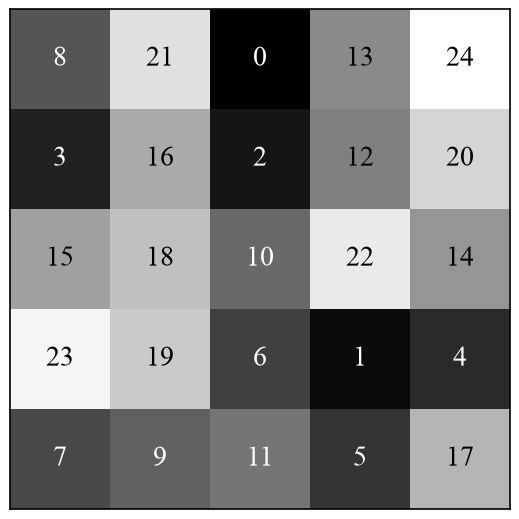

In [337]:
def create_asymmetric_matrix(n, seed=None):
    """
    Creates an n x n matrix with values from 0 to n²-1
    randomly distributed.
    """
    rng = np.random.default_rng(seed)
    values = np.arange(n * n)
    rng.shuffle(values)
    return values.reshape((n, n))


# Example
asymmetric = create_asymmetric_matrix(5, 10)

plt.figure(figsize=(5, 5))

plt.imshow(
    asymmetric,
    cmap="gray",
    origin="lower"
)

plt.xticks([])
plt.yticks([])

# Normalize values for choosing text color
vmin = np.min(asymmetric)
vmax = np.max(asymmetric)

for i in range(asymmetric.shape[0]):
    for j in range(asymmetric.shape[1]):

        value = asymmetric[i, j]

        # Normalize value to [0, 1]
        if vmax > vmin:
            normalized = (value - vmin) / (vmax - vmin)
        else:
            normalized = 0.5

        # Dark background -> white text
        # Bright background -> black text
        text_color = "white" if normalized < 0.5 else "black"

        plt.text(
            j,
            i,
            str(value),
            ha="center",
            va="center",
            color=text_color,
            fontsize=20
        )

plt.tight_layout(pad=0)

plt.show()

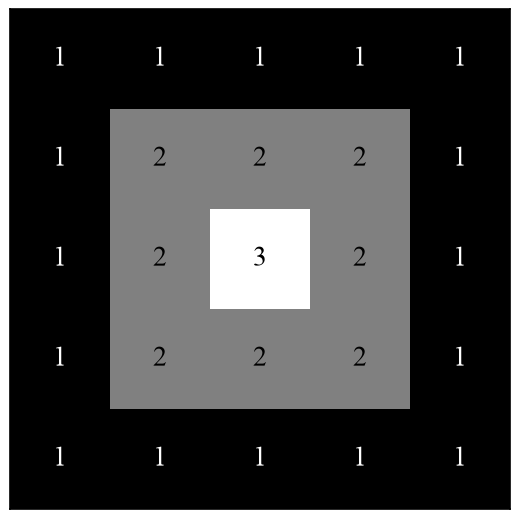

In [338]:
def create_symmetric_matrix(n):
    center = (n - 1) / 2
    matrix = np.zeros((n, n), dtype=int)

    for i in range(n):
        for j in range(n):
            distance = max(abs(i - center), abs(j - center))
            matrix[i, j] = int(center + 1 - distance)

    return matrix


symmetric = create_symmetric_matrix(5)

plt.figure(figsize=(5, 5))

plt.imshow(
    symmetric,
    cmap="gray",
    origin="lower"
)

plt.xticks([])
plt.yticks([])

# Normalize values for choosing text color
vmin = np.min(symmetric)
vmax = np.max(symmetric)

for i in range(symmetric.shape[0]):
    for j in range(symmetric.shape[1]):

        value = symmetric[i, j]

        # Normalize value to [0, 1]
        if vmax > vmin:
            normalized = (value - vmin) / (vmax - vmin)
        else:
            normalized = 0.5

        # Dark background -> white text
        # Bright background -> black text
        text_color = "white" if normalized < 0.5 else "black"

        plt.text(
            j,
            i,
            str(value),
            ha="center",
            va="center",
            color=text_color,
            fontsize=20
        )

plt.tight_layout(pad=0)

plt.show()

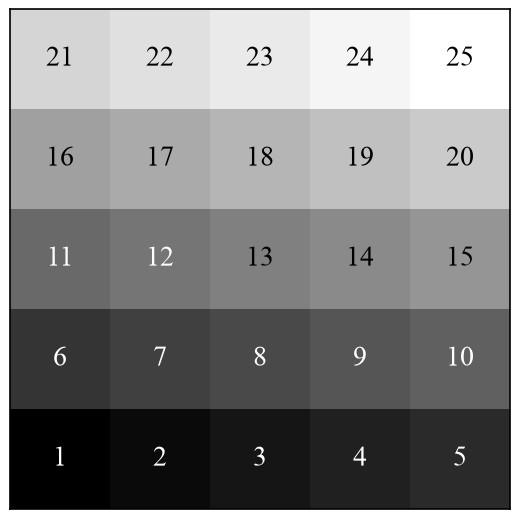

In [339]:
def create_laminar_matrix(n):
    """
    Creates an n x n matrix with increasing values row by row.
    """
    return np.arange(1, n * n + 1).reshape(n, n)


# Example
laminar = create_laminar_matrix(5)

plt.figure(figsize=(5, 5))

plt.imshow(
    laminar,
    cmap="gray",
    origin="lower"
)

plt.xticks([])
plt.yticks([])

# Normalize values for choosing text color
vmin = np.min(laminar)
vmax = np.max(laminar)

for i in range(laminar.shape[0]):
    for j in range(laminar.shape[1]):

        value = laminar[i, j]

        # Normalize value to [0, 1]
        if vmax > vmin:
            normalized = (value - vmin) / (vmax - vmin)
        else:
            normalized = 0.5

        # Dark background -> white text
        # Bright background -> black text
        text_color = "white" if normalized < 0.5 else "black"

        plt.text(
            j,
            i,
            str(value),
            ha="center",
            va="center",
            color=text_color,
            fontsize=20
        )

plt.tight_layout(pad=0)

plt.show()

[[ 7  9 11  5 17]
 [23 19  6  1  4]
 [15 18 10 22 14]
 [ 3 16  2 12 20]
 [ 8 21  0 13 24]]
Tolerance error: 0.9634895920753479
Tolerance error: 0.8858365416526794
Tolerance error: 0.9097264409065247
Tolerance error: 0.770965039730072
Tolerance error: 0.9658735394477844
Tolerance error: 0.7006597518920898
Tolerance error: 0.025406507775187492
Tolerance error: 0.7287665605545044
Tolerance error: 0.9784786701202393
Tolerance error: 0.5786488056182861
Tolerance error: 0.9016018509864807
Tolerance error: 0.854110598564148
Tolerance error: 0.26210692524909973
Tolerance error: 0.6820787787437439
Tolerance error: 0.9739571809768677
Tolerance error: 0.9972499012947083
Tolerance error: 0.3305968642234802
Tolerance error: 0.48033443093299866
Tolerance error: 0.4597637951374054
Tolerance error: 0.6671686172485352
Tolerance error: 0.9524198174476624
Tolerance error: 0.6816191077232361
Tolerance error: 0.9630619883537292
Tolerance error: 0.04449382424354553
Tolerance error: 0.6940370202064514
Tolera

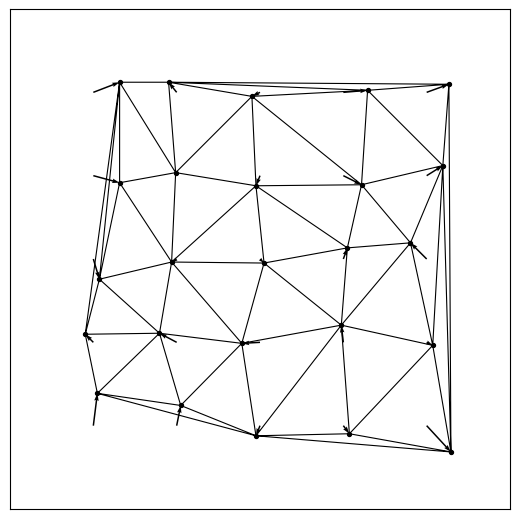

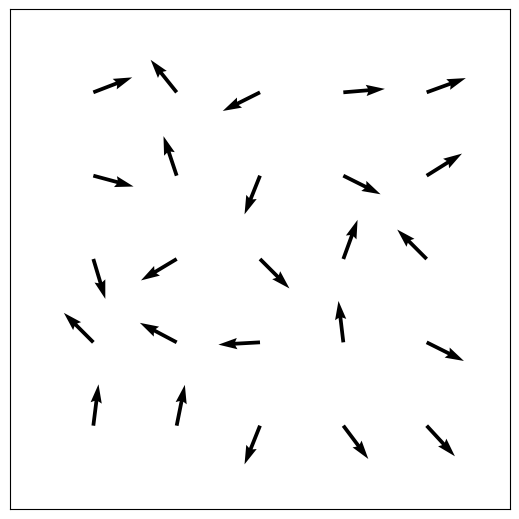

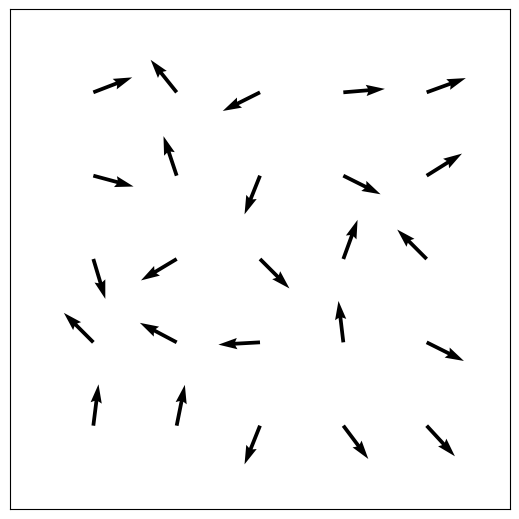

In [340]:
print(asymmetric)
gpaObject = GPA(asymmetric)
gpaObject.setPosition(2, 2)
ga = gpaObject.evaluate(mtol=0.019999999552965164, ftol=0.029999999329447746, ptol=0.009999999776482582)
print(ga)
gpaObject.plot_delaunay_triangulation(show_center=False, show_image=False, show_scale=False, line_color="black")
gpaObject.plot_gradient_field(show_center=False, show_image=False, show_scale=False, color="black", fixed_length=True)
gpaObject.plot_asymmetric_gradient_field(show_center=False, show_image=False, show_scale=False, color="black", fixed_length=True)

[[1 1 1 1 1]
 [1 2 2 2 1]
 [1 2 3 2 1]
 [1 2 2 2 1]
 [1 1 1 1 1]]
Tolerance error: 0.9262096881866455
Tolerance error: 0.7071067690849304
Tolerance error: 0.9262096881866455
Tolerance error: 0.41421353816986084
Tolerance error: 0.7071067690849304
Tolerance error: 0.41421353816986084
Tolerance error: 0.0
Tolerance error: 0.9262096881866455
Tolerance error: 0.7071067690849304
Tolerance error: 0.7071067690849304
Tolerance error: 0.41421353816986084
Tolerance error: 0.0
Tolerance error: 0.41421353816986084
Tolerance error: 0.9262096881866455
Tolerance error: 0.0
Tolerance error: 0.0
Tolerance error: 1.0
Tolerance error: 1.0
Tolerance error: 0.7071067690849304
Tolerance error: 0.7071067690849304
Tolerance error: 0.7071067690849304
Tolerance error: 0.7071067690849304
Tolerance error: 0.7071067690849304
Tolerance error: 0.7071067690849304
Tolerance error: 0.0
Tolerance error: 0.0
Tolerance error: 0.0
Tolerance error: 1.0
Tolerance error: 0.7071067690849304
Tolerance error: 0.7071067690849304


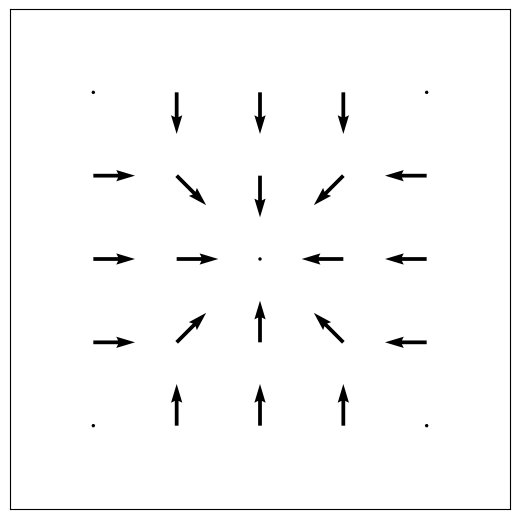

No asymmetric gradient vectors remaining.


In [341]:
print(symmetric)
gpaObject = GPA(symmetric)
gpaObject.setPosition((len(symmetric)-1)/2, (len(symmetric[0])-1)/2)
ga = gpaObject.evaluate(mtol=0.019999999552965164, ftol=0.029999999329447746, ptol=0.009999999776482582)
print(ga)
gpaObject.plot_delaunay_triangulation(show_center=False, show_image=False, show_scale=False, line_color="black")
gpaObject.plot_gradient_field(show_center=False, show_image=False, show_scale=False, color="black", fixed_length=True)
gpaObject.plot_asymmetric_gradient_field(show_center=False, show_image=False, show_scale=False, color="black", fixed_length=True)

In [342]:
# laminar[3][3]=10

[[ 1  2  3  4  5]
 [ 6  7  8  9 10]
 [11 12 13 14 15]
 [16 17 18 19 20]
 [21 22 23 24 25]]
Tolerance error: 1.0
Tolerance error: 1.0
Tolerance error: 1.0
Tolerance error: 1.0
Tolerance error: 1.0
Tolerance error: 1.0
Tolerance error: 1.0
Tolerance error: 1.0
Tolerance error: 1.0
Tolerance error: 1.0
Tolerance error: 1.0
Tolerance error: 1.0
Tolerance error: 1.0
Tolerance error: 1.0
Tolerance error: 1.0
Tolerance error: 1.0
Tolerance error: 1.0
Tolerance error: 1.0
Tolerance error: 1.0
Tolerance error: 1.0
Tolerance error: 1.0
Tolerance error: 1.0
Tolerance error: 1.0
Tolerance error: 1.0
Tolerance error: 1.0
Tolerance error: 1.0
Tolerance error: 1.0
Tolerance error: 1.0
Tolerance error: 1.0
Tolerance error: 1.0
Tolerance error: 1.0
Tolerance error: 1.0
Tolerance error: 1.0
Tolerance error: 1.0
Tolerance error: 1.0
Tolerance error: 1.0
Tolerance error: 1.0
Tolerance error: 1.0
Tolerance error: 1.0
Tolerance error: 1.0
Tolerance error: 1.0
Tolerance error: 1.0
Tolerance error: 1.0
Tolera

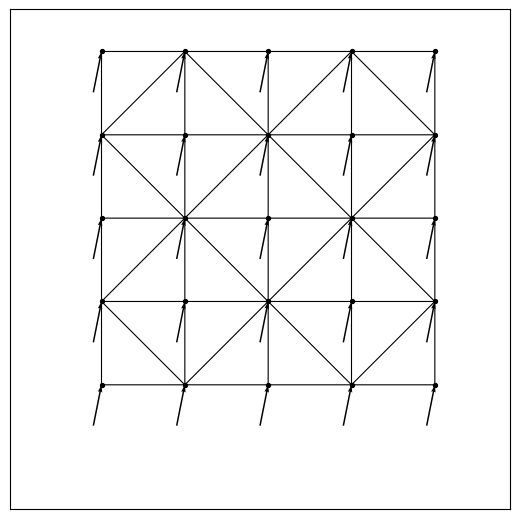

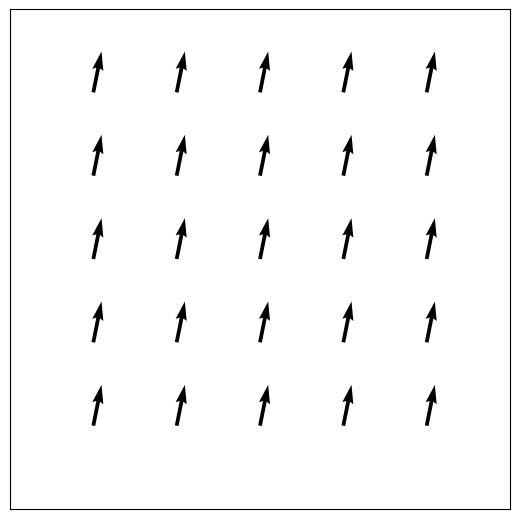

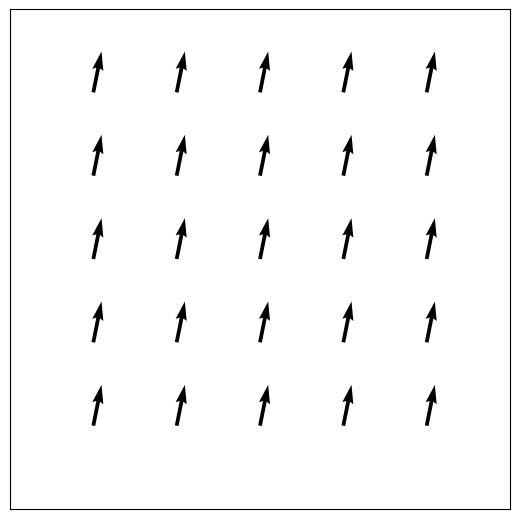

In [343]:
print(laminar)
gpaObject = GPA(laminar)
gpaObject.setPosition(1, 1)
ga = gpaObject.evaluate(mtol=0.019999999552965164, ftol=0.029999999329447746, ptol=0.009999999776482582)
print(ga)
gpaObject.plot_delaunay_triangulation(show_center=False, show_image=False, show_scale=False, line_color="black")
gpaObject.plot_gradient_field(show_center=False, show_image=False, show_scale=False, color="black", fixed_length=True)
gpaObject.plot_asymmetric_gradient_field(show_center=False, show_image=False, show_scale=False, color="black", fixed_length=True)

In [344]:
ex = np.array([[1, 3, 6],
 [5, 8, 4],
 [3, 2, 5]])

[[1 3 6]
 [5 8 4]
 [3 2 5]]
Tolerance error: 1.0
Tolerance error: 0.666671633720398
Tolerance error: 0.9262096881866455
Tolerance error: 0.4740683436393738
Tolerance error: 0.3333333134651184
Tolerance error: 0.34159979224205017
Tolerance error: 0.9262096881866455
Tolerance error: 0.681293249130249
Tolerance error: 0.9299582242965698
Tolerance error: 0.49301207065582275
Tolerance error: 0.4285714328289032
Tolerance error: 0.31183722615242004
Tolerance error: 0.9299582242965698
Tolerance error: 0.8987760543823242
Tolerance error: 0.35258546471595764
Tolerance error: 0.7655644416809082
Tolerance error: 0.9232020974159241
Tolerance error: 0.8987760543823242
Tolerance error: 0.1554248332977295
Tolerance error: 0.41421353816986084
Tolerance error: 0.6926009654998779
Tolerance error: 1.0
Tolerance error: 0.8919729590415955
Tolerance error: 0.707829475402832
Tolerance error: 0.1554248332977295
Tolerance error: 0.9616736173629761
Tolerance error: 0.41421353816986084
Tolerance error: 0.69260096

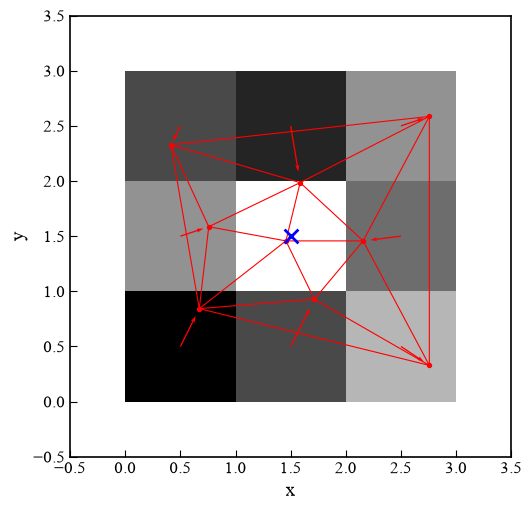

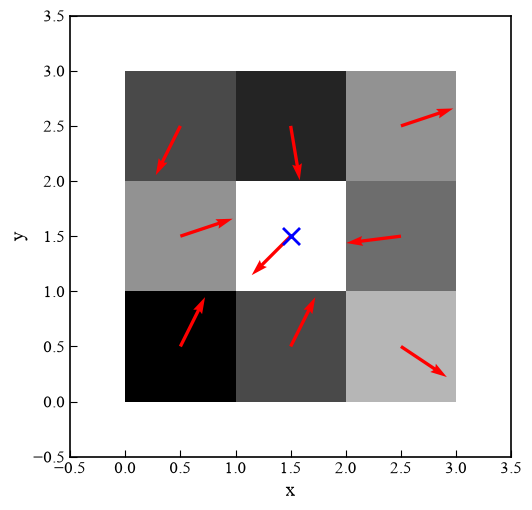

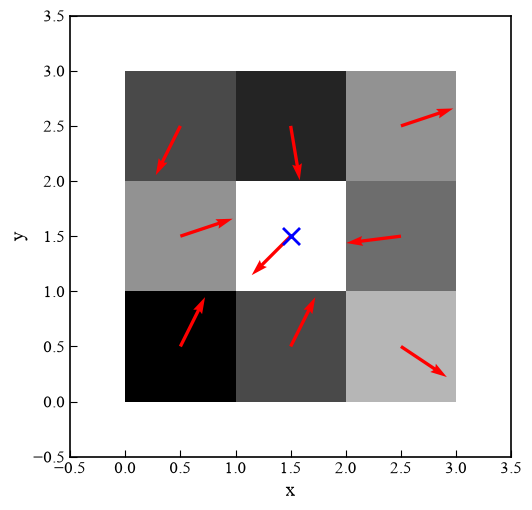

In [345]:
print(ex)
gpaObject = GPA(ex)
ga = gpaObject.evaluate(mtol=0.019999999552965164, ftol=0.029999999329447746, ptol=0.009999999776482582)
print(ga)
gpaObject.plot_delaunay_triangulation()
gpaObject.plot_gradient_field(fixed_length=True)
gpaObject.plot_asymmetric_gradient_field(fixed_length=True)